In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ==========================================
# 1. Advanced Kalman Filter (with Control Input)
# ==========================================
class KalmanFilterFusion:
    def __init__(self, dt, process_noise_std, measurement_noise_std, initial_state):
        self.dt = dt
        
        # State Vector [p, v]
        self.x = np.array(initial_state).reshape(2, 1)
        
        # Covariance Matrix P
        self.P = np.eye(2) * 100.0 
        
        # State Transition Matrix F
        self.F = np.array([[1, self.dt],
                           [0, 1]])
        
        # Control Input Matrix B (For Acceleration)
        self.B = np.array([[0.5 * self.dt**2],
                           [self.dt]])
        
        # Observation Matrix H
        self.H = np.array([[1, 0]])
        
        # Process Noise Q (Model Uncertainty)
        # Even with IMU, we have some uncertainty in the physics
        self.Q = np.array([[0.01, 0], [0, 0.01]])
        
        # Measurement Noise R (Ultrasonic Uncertainty)
        self.R = np.array([[measurement_noise_std ** 2]])

    def predict(self, u):
        """
        Predict step now takes 'u' (Acceleration from IMU)
        """
        self.x = (self.F @ self.x) + (self.B * u)
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x

    def update(self, z):
        """Standard Correction Step using Ultrasonic data"""
        y = z - (self.H @ self.x)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + (K @ y)
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P
        return self.x

In [3]:
# ==========================================
# 2. Simulation Utilities
# ==========================================
def generate_ground_truth(total_time, dt):
    """
    Simulates a car driving towards a wall, then braking hard.
    """
    steps = int(total_time / dt)
    times = np.linspace(0, total_time, steps)
    
    true_pos = []
    true_vel = []
    true_acc = []
    
    # Initial Conditions
    p = 60.0 # Starting distance
    v = -10.0 # Moving fast towards object (-10 m/s)
    a = 0.0
    
    for t in times:
        # Scenario: At t=2s, BRAKE HARD (decelerate)
        if 2.0 < t < 5.0:
            a = 3.0 # Decelerate (positive acceleration opposes negative velocity)
        else:
            a = 0.0
            
        # Physics Update
        p += v * dt + 0.5 * a * dt**2
        v += a * dt
        
        # Stop if we hit the object or stop moving
        if v > 0: v = 0 
        if p < 0: p = 0
            
        true_pos.append(p)
        true_vel.append(v)
        true_acc.append(a)
        
    return times, np.array(true_pos), np.array(true_vel), np.array(true_acc)

def add_sensor_noise(true_pos, true_acc, meas_std_pos, meas_std_acc):
    """Adds Gaussian noise to Position (Ultrasonic) and Accel (IMU)"""
    z_pos = true_pos + np.random.normal(0, meas_std_pos, len(true_pos))
    u_acc = true_acc + np.random.normal(0, meas_std_acc, len(true_acc))
    return z_pos, u_acc

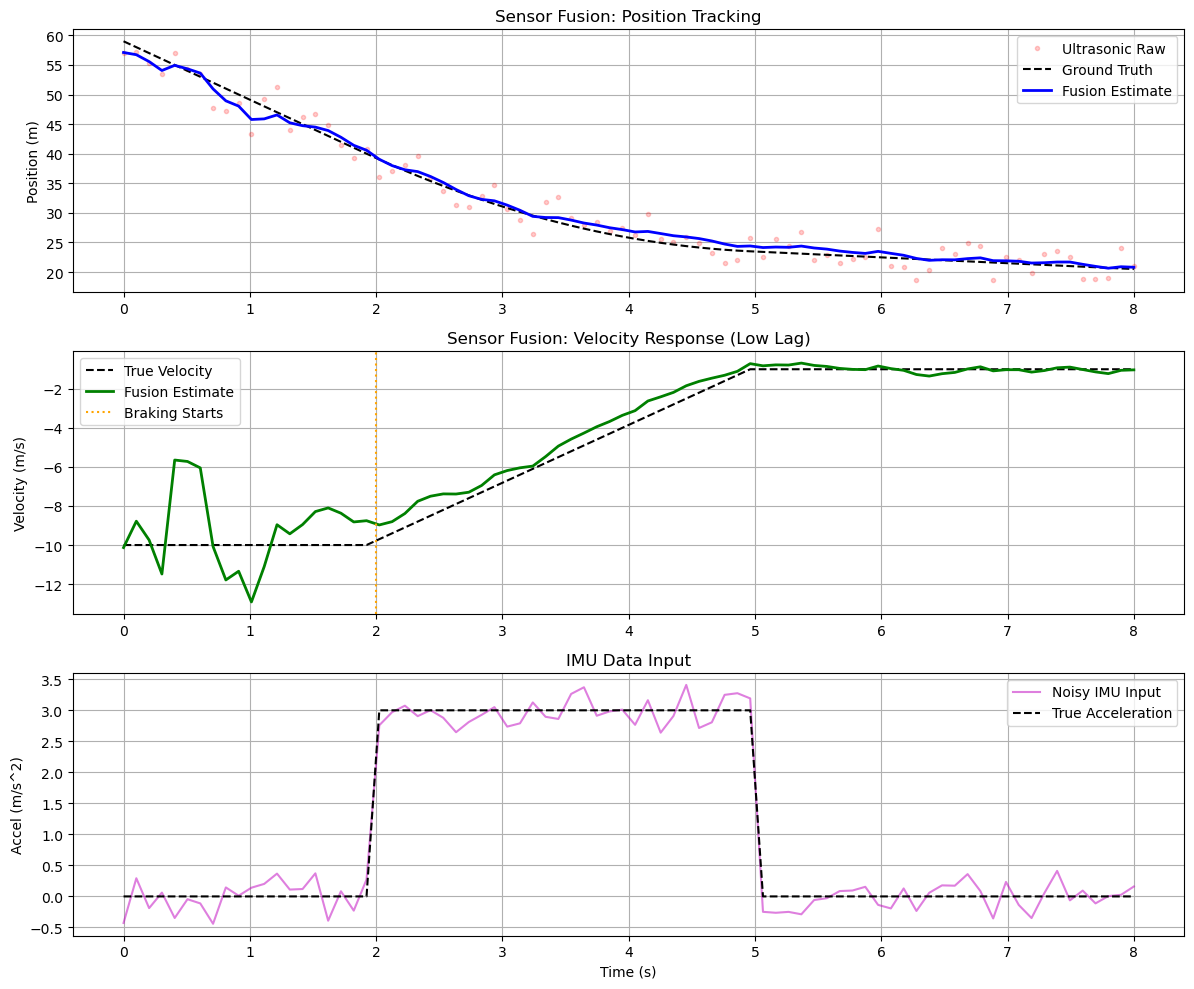

In [4]:
# ==========================================
# 3. Main Execution Pipeline
# ==========================================
def run_fusion_simulation():
    # Setup
    dt = 0.1
    total_time = 8.0
    
    # 1. Generate Truth (The Scenario)
    t, t_pos, t_vel, t_acc = generate_ground_truth(total_time, dt)
    
    # 2. Generate Noisy Sensor Data
    # Ultrasonic is noisy (std=2.0m), IMU is relatively clean (std=0.2m/s^2)
    z_meas, u_meas = add_sensor_noise(t_pos, t_acc, meas_std_pos=2.0, meas_std_acc=0.2)
    
    # 3. Initialize Filters
    # Filter A: Sensor Fusion (Uses IMU)
    kf_fusion = KalmanFilterFusion(dt, 0.1, 2.0, [t_pos[0], t_vel[0]])
    
    # Filter B: Basic CV (For comparison - relies only on position)
    # We construct a temporary class or just imagine the lag, 
    # but let's run the fusion to see the result.
    
    history = []
    
    for i in range(len(t)):
        # Sensor Readings at this step
        z = z_meas[i]      # Ultrasonic
        u = u_meas[i]      # IMU (Accelerometer)
        
        # --- PREDICT (Physics driven by IMU) ---
        kf_fusion.predict(u)
        
        # --- UPDATE (Correction driven by Ultrasonic) ---
        est_state = kf_fusion.update(z)
        
        # Log
        history.append({
            'Time': t[i],
            'True_Vel': t_vel[i],
            'Est_Vel_Fusion': est_state[1, 0],
            'True_Pos': t_pos[i],
            'Raw_Pos': z,
            'Est_Pos_Fusion': est_state[0, 0]
        })
        
    df = pd.DataFrame(history)
    
    # ==========================================
    # 4. Visualization
    # ==========================================
    plt.figure(figsize=(12, 10))
    
    # Plot 1: Position
    plt.subplot(3, 1, 1)
    plt.plot(df['Time'], df['Raw_Pos'], 'r.', alpha=0.2, label='Ultrasonic Raw')
    plt.plot(df['Time'], df['True_Pos'], 'k--', label='Ground Truth')
    plt.plot(df['Time'], df['Est_Pos_Fusion'], 'b-', linewidth=2, label='Fusion Estimate')
    plt.ylabel('Position (m)')
    plt.title('Sensor Fusion: Position Tracking')
    plt.legend()
    plt.grid(True)
    
    # Plot 2: Velocity (The critical part)
    plt.subplot(3, 1, 2)
    plt.plot(df['Time'], df['True_Vel'], 'k--', label='True Velocity')
    plt.plot(df['Time'], df['Est_Vel_Fusion'], 'g-', linewidth=2, label='Fusion Estimate')
    plt.axvline(x=2.0, color='orange', linestyle=':', label='Braking Starts')
    plt.ylabel('Velocity (m/s)')
    plt.title('Sensor Fusion: Velocity Response (Low Lag)')
    plt.legend()
    plt.grid(True)
    
    # Plot 3: The Input Data (IMU)
    plt.subplot(3, 1, 3)
    plt.plot(t, u_meas, 'm-', alpha=0.5, label='Noisy IMU Input')
    plt.plot(t, t_acc, 'k--', label='True Acceleration')
    plt.xlabel('Time (s)')
    plt.ylabel('Accel (m/s^2)')
    plt.title('IMU Data Input')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_fusion_simulation()